# Tier 3 · Notebook 15 — Mixed Precision & Numerics

> **Goal:** understand the number formats that large-model training actually runs in — **fp32, fp16, bf16** — *why* naive fp16 training silently breaks, how **loss scaling** rescues it, and why **bf16** became the default for training LLMs. Half-precision roughly **halves memory and doubles throughput**, so this is not a detail — it's how training at scale is even affordable.

**The core tension.** A floating-point number spends its bits on two things:
- **exponent bits** → *dynamic range* (how big and how small a number it can represent), and
- **mantissa bits** → *precision* (how finely it resolves values near a given magnitude).

Fewer total bits means you must sacrifice one or both. The three formats make different sacrifices, and understanding those sacrifices explains every mixed-precision bug and best practice.


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline

# the three formats: (name, exponent bits, mantissa bits)
fmts = [("fp32", 8, 23), ("fp16", 5, 10), ("bf16", 8, 7)]
print(f"{'format':6s} {'exp':>4s} {'mant':>5s} {'max':>12s} {'min normal':>12s}")
for name, e, m in fmts:
    bias = 2**(e-1) - 1
    max_val = (2 - 2**-m) * 2**(2**e - 2 - bias)
    min_normal = 2**(1 - bias)
    print(f"{name:6s} {e:>4d} {m:>5d} {max_val:>12.2e} {min_normal:>12.2e}")
print("\nKey: fp16 and bf16 are both 16-bit, but split their bits very differently.")


format  exp  mant          max   min normal
fp32      8    23     3.40e+38     1.18e-38
fp16      5    10     6.55e+04     6.10e-05
bf16      8     7     3.39e+38     1.18e-38

Key: fp16 and bf16 are both 16-bit, but split their bits very differently.


## 0. Dynamic range: fp16's fatal weakness

Notice from the table: **fp16 and bf16 are both 16 bits**, but fp16 spends 5 bits on exponent / 10 on mantissa, while bf16 spends **8 on exponent** (same as fp32!) / 7 on mantissa. Consequences:
- **fp16**: max ≈ **65,504**, smallest normal ≈ **6×10⁻⁵**. Narrow range — numbers outside it overflow to `inf` or underflow to `0`. But *within* range, it's more precise than bf16 (10 mantissa bits).
- **bf16**: the **same enormous range as fp32** (max ≈ 3×10³⁸), but only 7 mantissa bits — coarser precision, yet it essentially never overflows/underflows.

Let's *see* the range difference by trying to represent very large and very small numbers.


In [2]:
test_vals = [1e-8, 1e-5, 1e-4, 1.0, 1e4, 1e5, 6e4, 1e30]
print(f"{'value':>10s} {'fp32':>14s} {'fp16':>14s} {'bf16':>14s}")
for v in test_vals:
    t = torch.tensor(v, dtype=torch.float32)
    f16 = t.half().item(); b16 = t.bfloat16().item()
    print(f"{v:>10.0e} {t.item():>14.3e} {f16:>14.3e} {b16:>14.3e}")
print("\nWatch: 1e-8 UNDERFLOWS to 0 in fp16; 1e30 OVERFLOWS to inf in fp16; bf16 handles both.")


     value           fp32           fp16           bf16
     1e-08      1.000e-08      0.000e+00      1.001e-08
     1e-05      1.000e-05      1.001e-05      1.001e-05
     1e-04      1.000e-04      1.000e-04      1.001e-04
     1e+00      1.000e+00      1.000e+00      1.000e+00
     1e+04      1.000e+04      1.000e+04      9.984e+03
     1e+05      1.000e+05            inf      9.984e+04
     6e+04      6.000e+04      6.000e+04      5.990e+04
     1e+30      1.000e+30            inf      1.000e+30

Watch: 1e-8 UNDERFLOWS to 0 in fp16; 1e30 OVERFLOWS to inf in fp16; bf16 handles both.


**What to notice.** In **fp16**, `1e-8` becomes exactly **0** (underflow — it's below the smallest representable value) and `1e30` becomes **inf** (overflow). Both are catastrophic in training: an underflowed *gradient* is a lost learning signal; an overflowed *activation* poisons everything downstream with NaNs. **bf16** represents both fine (just coarsely) because it kept fp32's exponent. This single difference — range — is why bf16 is preferred for training even though fp16 is technically *more precise* in its narrow band. Small gradients are exactly the thing that underflows fp16, which is the problem we solve next.


## 1. Precision: the gaps between representable numbers

Precision (mantissa bits) controls how finely a format resolves values. Floating point isn't a uniform grid — the gap between consecutive representable numbers *grows* with magnitude (that's what "floating" means). With fewer mantissa bits, the gaps are bigger, so rounding error is larger. Let's visualize the rounding error of each format across magnitudes.


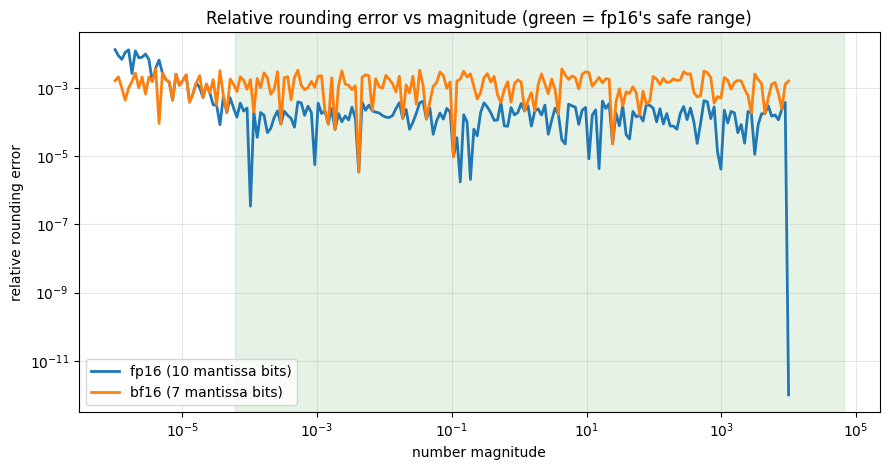

In [3]:
mags = np.logspace(-6, 4, 200)
def round_err(dtype):
    errs = []
    for m in mags:
        t = torch.tensor(float(m), dtype=torch.float32)
        r = t.to(dtype).float().item()
        errs.append(abs(r - m) / m if m != 0 else 0)     # relative error
    return np.array(errs)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(mags, round_err(torch.float16) + 1e-12, label="fp16 (10 mantissa bits)", lw=2)
ax.plot(mags, round_err(torch.bfloat16) + 1e-12, label="bf16 (7 mantissa bits)", lw=2)
ax.axvspan(6e-5, 65504, alpha=0.1, color="green")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("Relative rounding error vs magnitude (green = fp16's safe range)")
ax.set_xlabel("number magnitude"); ax.set_ylabel("relative rounding error")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()


**What to notice.** Within fp16's range (green band), **fp16 has smaller rounding error** than bf16 (more mantissa bits = finer resolution) — its error floor is ~$10^{-3}$ vs bf16's ~$10^{-2}$. But bf16's error stays bounded *everywhere*, while fp16 would shoot to 100% error (→0 or →inf) outside the green band. This is the whole tradeoff in one plot: **fp16 = more precise but fragile range; bf16 = coarser but robust range.** For training — where gradients span many orders of magnitude — robustness of range beats precision, so bf16 wins. For inference (values are better-behaved), fp16 is common.


## 2. The fp16 training bug: gradient underflow

Here's the actual failure. During training, gradients can be extremely tiny. fp16's smallest *normal* number is ~$6\times10^{-5}$; below that it uses less-precise *subnormals* down to ~$6\times10^{-8}$, and **anything below ~$6\times10^{-8}$ flushes to exactly 0** — those gradients vanish and their weights never update. Training stalls or diverges, silently. Let's demonstrate on a distribution of very small gradients straddling that cliff.


gradient magnitudes: median 1.52e-08, range [2.3e-11, 1.4e-05]
fraction that UNDERFLOW to 0 in fp16: 67.2%
fraction that underflow in bf16     : 0.0%  (bf16 reaches ~1e-38)


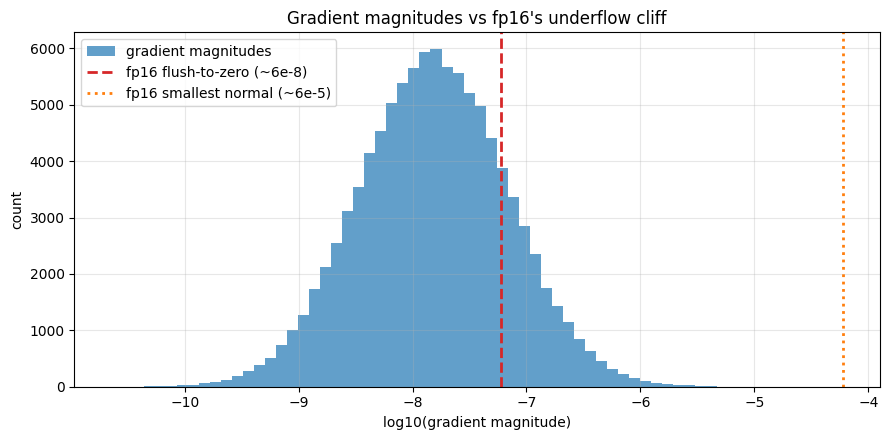

In [4]:
torch.manual_seed(0)
# a distribution of tiny gradients straddling fp16's flush-to-zero point (~6e-8)
grads = torch.exp(torch.randn(100000) * 1.5 - 18).float()   # median ~1.5e-8
print(f"gradient magnitudes: median {grads.median():.2e}, range [{grads.min():.1e}, {grads.max():.1e}]")
print(f"fraction that UNDERFLOW to 0 in fp16: {(grads.half()==0).float().mean()*100:.1f}%")
print(f"fraction that underflow in bf16     : {(grads.bfloat16()==0).float().mean()*100:.1f}%  (bf16 reaches ~1e-38)")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(np.log10(grads.numpy()+1e-45), bins=60, alpha=0.7, color="tab:blue", label="gradient magnitudes")
ax.axvline(np.log10(6e-8), color="tab:red", ls="--", lw=2, label="fp16 flush-to-zero (~6e-8)")
ax.axvline(np.log10(6e-5), color="tab:orange", ls=":", lw=2, label="fp16 smallest normal (~6e-5)")
ax.set_title("Gradient magnitudes vs fp16's underflow cliff")
ax.set_xlabel("log10(gradient magnitude)"); ax.set_ylabel("count"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**What to notice.** A large fraction of the gradients fall **below fp16's underflow threshold** (red line) and become exactly 0 — those weights get *no update this step*. Do this every step and training silently degrades or stalls. bf16 barely underflows any (its range extends down to ~$10^{-38}$). This is *the* reason you can't just cast a model to fp16 and train. The classic fix (for when you must use fp16, e.g. on hardware without bf16) is **loss scaling**.


## 3. Loss scaling — shift gradients into fp16's range

The trick is beautifully simple. Before calling `backward()`, multiply the loss by a large constant $S$ (say $2^{16}$). By the chain rule, *every gradient* gets multiplied by $S$ too — shifting the whole gradient distribution **up** into fp16's representable range, so small gradients no longer underflow. Then, before the optimizer step, **divide the gradients back by $S$** (unscale) to recover the true values. The scaling cancels exactly; it's just a temporary shift to dodge the underflow cliff. Modern frameworks do this *dynamically* (auto-tuning $S$, backing off on overflow).


In [5]:
S = 2**16                                          # loss scale factor
scaled = grads * S                                  # what backward() would produce with loss scaling
recovered = scaled.half().float() / S               # store in fp16, then unscale

frac_lost_noscale = (grads.half() == 0).float().mean().item()
frac_lost_scaled  = ((scaled.half() == 0) & (grads > 0)).float().mean().item()
print(f"without loss scaling: {frac_lost_noscale*100:.1f}% of gradients underflow to 0")
print(f"with loss scaling S=2^16: {frac_lost_scaled*100:.1f}% underflow")
rel_err = ((recovered - grads).abs() / grads)[grads > 1e-7].median().item()
print(f"median relative error of recovered gradients: {rel_err:.2e}  (they survived!)")
print("\nLoss scaling rescued the small gradients that fp16 would otherwise have zeroed.")


without loss scaling: 67.2% of gradients underflow to 0
with loss scaling S=2^16: 0.0% underflow
median relative error of recovered gradients: 1.68e-04  (they survived!)

Loss scaling rescued the small gradients that fp16 would otherwise have zeroed.


**What to notice.** With loss scaling, the fraction of gradients lost to underflow drops dramatically — the multiply-by-$S$ lifted them above the cliff, and dividing back recovered their true values with small error. This is exactly what `torch.cuda.amp.GradScaler` automates: scale the loss, backward in fp16, unscale, step. Loss scaling is the price of using fp16. **bf16 needs none of this** — its range already covers the gradients — which is a big part of why it took over.


## 4. Mixed precision, the full recipe

"Mixed precision" means: do the heavy **compute** (matmuls) in fast 16-bit, but keep a **master copy of the weights in fp32** and accumulate updates there. Why the fp32 master copy? Because weight *updates* are often tinier than the weights themselves ($w \mathrel{-}= \text{lr}\cdot g$ where $\text{lr}\cdot g \ll w$), and in 16-bit that update would round away to nothing (the update is smaller than the gap between representable 16-bit numbers near $w$). Keeping weights in fp32 preserves those small updates.

The recipe (what `autocast` + `GradScaler` implement):
1. **Forward** in 16-bit (fast, half the memory).
2. **Scale** the loss (fp16 only) and **backward** in 16-bit.
3. **Unscale** and **update the fp32 master weights**.
4. Cast master weights back to 16-bit for the next forward.

Let's demonstrate the "small update rounds away" problem that motivates the fp32 master copy.


In [6]:
w = 1.0                     # a weight of magnitude ~1
update = 1e-4               # a typical small update (lr * grad)

# update entirely in fp16 vs keeping an fp32 master
w_fp16 = torch.tensor(w, dtype=torch.float16)
w_after_fp16 = (w_fp16 + torch.tensor(update, dtype=torch.float16)).item()
w_fp32 = torch.tensor(w, dtype=torch.float32)
w_after_fp32 = (w_fp32 + torch.tensor(update, dtype=torch.float32)).item()

print(f"weight {w}, update {update}")
print(f"  fp16 update:  {w} + {update} = {w_after_fp16}   (change: {w_after_fp16 - w:.2e})")
print(f"  fp32 update:  {w} + {update} = {w_after_fp32}   (change: {w_after_fp32 - w:.2e})")
print("\nIn fp16, the tiny update is SMALLER than the gap between representable numbers near 1.0,")
print("so w + update rounds right back to w — the update is lost. fp32 master weights preserve it.")

# how many such updates get lost accumulating in fp16 vs fp32?
wf16 = torch.tensor(1.0, dtype=torch.float16); wf32 = torch.tensor(1.0, dtype=torch.float32)
for _ in range(1000):
    wf16 = (wf16 + torch.tensor(1e-4, dtype=torch.float16)).half()
    wf32 = wf32 + 1e-4
print(f"\nafter 1000 updates of +1e-4:  fp16-only = {wf16.item():.4f}   fp32-master = {wf32.item():.4f}   (true = 1.1000)")


weight 1.0, update 0.0001
  fp16 update:  1.0 + 0.0001 = 1.0   (change: 0.00e+00)
  fp32 update:  1.0 + 0.0001 = 1.000100016593933   (change: 1.00e-04)

In fp16, the tiny update is SMALLER than the gap between representable numbers near 1.0,
so w + update rounds right back to w — the update is lost. fp32 master weights preserve it.

after 1000 updates of +1e-4:  fp16-only = 1.0000   fp32-master = 1.1000   (true = 1.1000)


**What to notice.** A single $10^{-4}$ update to a weight of ~1.0 **completely disappears in fp16** (the update is finer than fp16's resolution near 1.0), so 1000 such updates leave the fp16 weight *unchanged at 1.0*, while the fp32 master correctly reaches 1.1. This is why every mixed-precision recipe keeps **master weights in fp32** — the compute is cheap in 16-bit, but the *accumulation of small updates* needs fp32. Together with loss scaling (fp16) or bf16's wide range, this is the complete picture of how huge models train in half precision.

## 5. What you built / learned
- The **range vs precision** tradeoff: fp16 (narrow range, more precise), bf16 (fp32's range, less precise), fp32.
- fp16's **overflow/underflow** and why small **gradients vanish** in it.
- **Loss scaling**: shift gradients into fp16's range with a multiply, unscale before the step.
- Why **bf16 won** for training: same range as fp32, no loss scaling needed.
- **Mixed precision**: 16-bit compute + **fp32 master weights** (so tiny updates aren't rounded away).

## 6. Exercises
1. **Dynamic loss scaling.** Implement it: start with a large $S$, halve it whenever gradients overflow (inf/nan), grow it slowly otherwise. This is what `GradScaler` does.
2. **fp8.** Look up the two fp8 formats (E4M3, E5M2) used in H100 training. What ranges/precisions do they have, and where is each used (forward vs backward)?
3. **Accumulation dtype.** In a big reduction (summing $10^6$ numbers), compare the error of fp16 vs fp32 accumulation. Why do matmul kernels accumulate in fp32 even with fp16 inputs?
4. **Real AMP.** Train a small model with `torch.autocast` + `GradScaler` vs plain fp32; compare memory, speed, and final loss.
5. **Where NOT to use low precision.** Softmax, LayerNorm, and loss are often kept in fp32 even under autocast — why? (Hint: sums of exponentials, variance.)
6. **bf16 vs fp16 training.** Train the same model in each; does fp16 need loss scaling to match bf16? Does bf16 ever need it?

## 7. Interview / residency framing
- *"fp16 vs bf16?"* → both 16-bit; fp16 = 5 exp/10 mant (narrow range, more precise), bf16 = 8 exp/7 mant (fp32's range, less precise). bf16 preferred for training (no overflow/underflow, no loss scaling).
- *"Why does naive fp16 training break?"* → small gradients underflow to 0 (below ~6e-5); overflow to inf/nan; learning signal lost.
- *"What is loss scaling?"* → multiply loss by S before backward to lift gradients into fp16's range, divide back before the step; the scaling cancels exactly.
- *"Why keep fp32 master weights?"* → updates (lr·grad) are often smaller than 16-bit resolution near the weight, so they'd round away; fp32 accumulation preserves them.
- *"What does mixed precision buy?"* → ~2× memory and throughput from 16-bit compute, with fp32 master weights + loss scaling for correctness.

---
**Next:** *Tier 3 · Notebook 16 — Efficient / Flash attention*: the $O(n^2)$ memory problem of attention and how FlashAttention's tiling + online softmax makes it $O(n)$ memory — the algorithm that unlocked long context.


## 📚 References & papers

This notebook reproduces / builds on:

- **Mixed Precision Training** — Micikevicius et al. (2017), arXiv:1710.03740. Loss scaling, fp32 master weights.
- **FP8 Formats for Deep Learning** — Micikevicius et al. (2022), arXiv:2209.05433.